# Capitulo 2 - Precios, retornos y rendimiento acumulado

Este notebook descarga precios financieros, calcula retornos simples y logaritmicos, construye rendimiento acumulado y estima drawdown. El objetivo es comparar desempeno y riesgo sin confundir precios con retornos.

In [1]:
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf


def find_book_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if candidate.name == "econometria_financiera_python" and (candidate / "PROJECT_BRIEF.md").exists():
            return candidate
    raise FileNotFoundError("No se encontro la raiz del libro econometria_financiera_python.")


BOOK_ROOT = find_book_root(Path.cwd().resolve())
DATA_RAW = BOOK_ROOT / "data" / "raw"
DATA_PROCESSED = BOOK_ROOT / "data" / "processed"
OUTPUT_TABLES = BOOK_ROOT / "outputs" / "tables"
OUTPUT_FIGURES = BOOK_ROOT / "outputs" / "figures"
OUTPUT_REPORTS = BOOK_ROOT / "outputs" / "reports"

for folder in [DATA_RAW, DATA_PROCESSED, OUTPUT_TABLES, OUTPUT_FIGURES, OUTPUT_REPORTS]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Libro: {BOOK_ROOT.name}")

Libro: econometria_financiera_python


## 1. Descargar precios

Usamos activos con perfiles distintos: acciones amplias, tecnologia y bonos de largo plazo.

In [2]:
tickers = ["SPY", "QQQ", "TLT"]
start_date = "2020-01-01"
download_timestamp = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M:%S UTC")

prices_raw = yf.download(
    tickers=tickers,
    start=start_date,
    auto_adjust=False,
    progress=False,
    group_by="column",
)

raw_path = DATA_RAW / "chapter_02_precios_yfinance_raw.csv"
prices_raw.to_csv(raw_path, encoding="utf-8")

print(f"Fecha de descarga: {download_timestamp}")
print(f"Archivo raw: {raw_path.relative_to(BOOK_ROOT)}")
print(f"Filas descargadas: {len(prices_raw):,}")

Fecha de descarga: 2026-05-06 06:34:31 UTC
Archivo raw: data\raw\chapter_02_precios_yfinance_raw.csv
Filas descargadas: 1,593


## 2. Construir retornos

Usamos precio ajustado cuando esta disponible. Luego calculamos retorno simple y retorno logaritmico.

In [3]:
if isinstance(prices_raw.columns, pd.MultiIndex) and "Adj Close" in prices_raw.columns.get_level_values(0):
    prices = prices_raw["Adj Close"].copy()
    price_field = "Adj Close"
elif isinstance(prices_raw.columns, pd.MultiIndex) and "Close" in prices_raw.columns.get_level_values(0):
    prices = prices_raw["Close"].copy()
    price_field = "Close"
else:
    raise ValueError("No se encontro Adj Close ni Close en la descarga.")

prices = prices.dropna(how="all")
returns_simple = prices.pct_change(fill_method=None).dropna(how="all")
returns_log = np.log(prices / prices.shift(1)).dropna(how="all")
wealth_index = (1 + returns_simple.fillna(0)).cumprod()
running_max = wealth_index.cummax()
drawdown = wealth_index / running_max - 1

print(f"Campo usado: {price_field}")
returns_log.tail()

Campo usado: Adj Close


Ticker,QQQ,SPY,TLT
Date,,,
2026-04-29,0.006095,-0.000155,-0.007788
2026-04-30,0.009283,0.009900,-0.000934
2026-05-01,0.009554,0.002765,0.003569
2026-05-04,-0.001886,-0.003670,-0.007622
2026-05-05,0.012891,0.007990,0.005517


## 3. Tabla de riesgo y retorno

El resumen combina retorno promedio, volatilidad y maximo drawdown. Son estadisticas descriptivas, no recomendaciones.

In [4]:
summary = pd.DataFrame({
    "media_diaria_log": returns_log.mean(),
    "volatilidad_diaria_log": returns_log.std(),
    "volatilidad_anualizada_aprox": returns_log.std() * np.sqrt(252),
    "rendimiento_acumulado": wealth_index.iloc[-1] - 1,
    "max_drawdown": drawdown.min(),
    "observaciones": returns_log.count(),
})
summary

,media_diaria_log,volatilidad_diaria_log,volatilidad_anualizada_aprox,rendimiento_acumulado,max_drawdown,observaciones
Ticker,,,,,,
QQQ,0.000745,0.015758,0.250148,2.271976,-0.351187,1592
SPY,0.000560,0.012905,0.204857,1.437854,-0.337173,1592
TLT,-0.000180,0.010573,0.167846,-0.248944,-0.483511,1592


## 4. Grafico de rendimiento acumulado

Cada activo empieza en 1. Esto permite comparar crecimiento relativo.

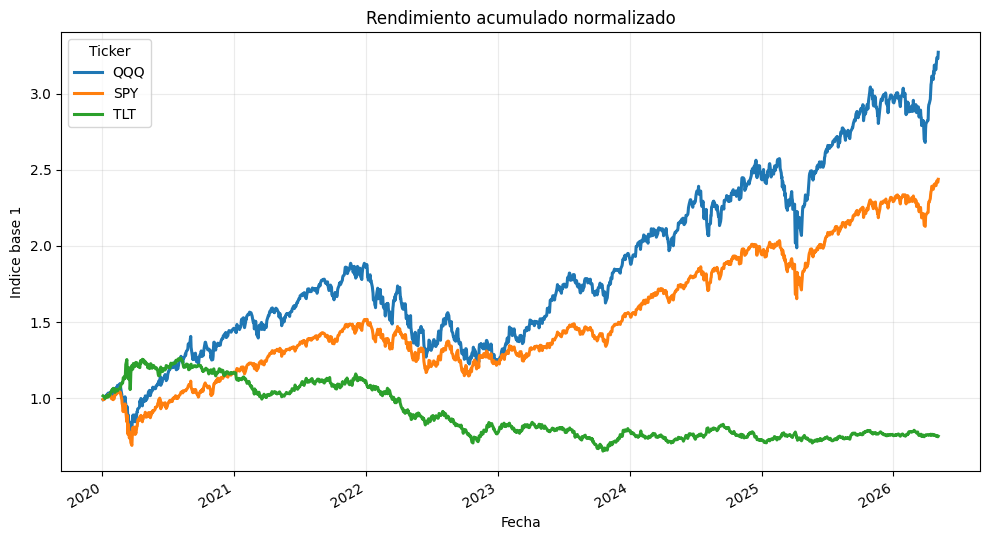

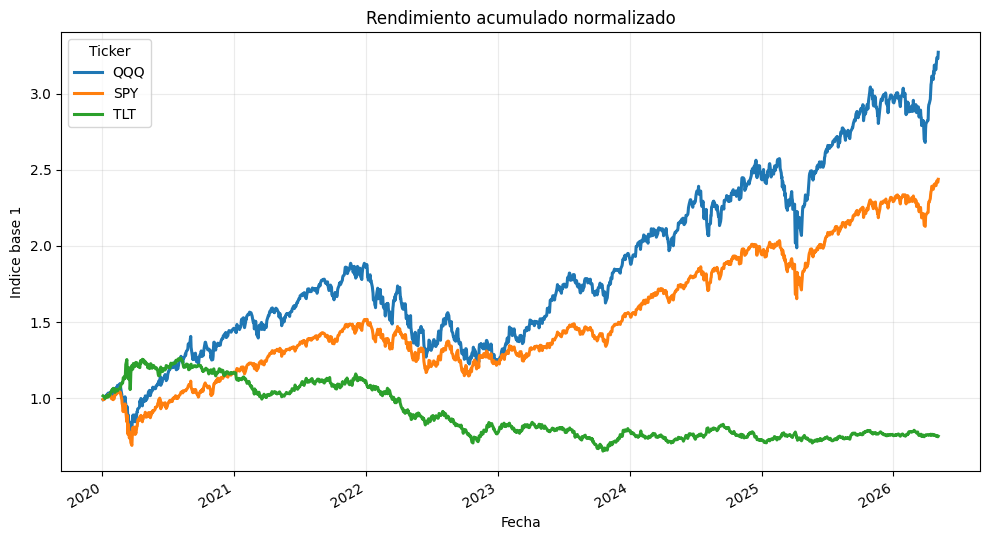

In [5]:
fig_acc, ax = plt.subplots(figsize=(10, 5.5))
wealth_index.plot(ax=ax, linewidth=2.2)
ax.set_title("Rendimiento acumulado normalizado")
ax.set_ylabel("Indice base 1")
ax.set_xlabel("Fecha")
ax.grid(True, alpha=0.25)
ax.legend(title="Ticker")
fig_acc.tight_layout()
fig_acc

## 5. Grafico de drawdown

El drawdown muestra perdidas porcentuales desde maximos previos del indice acumulado.

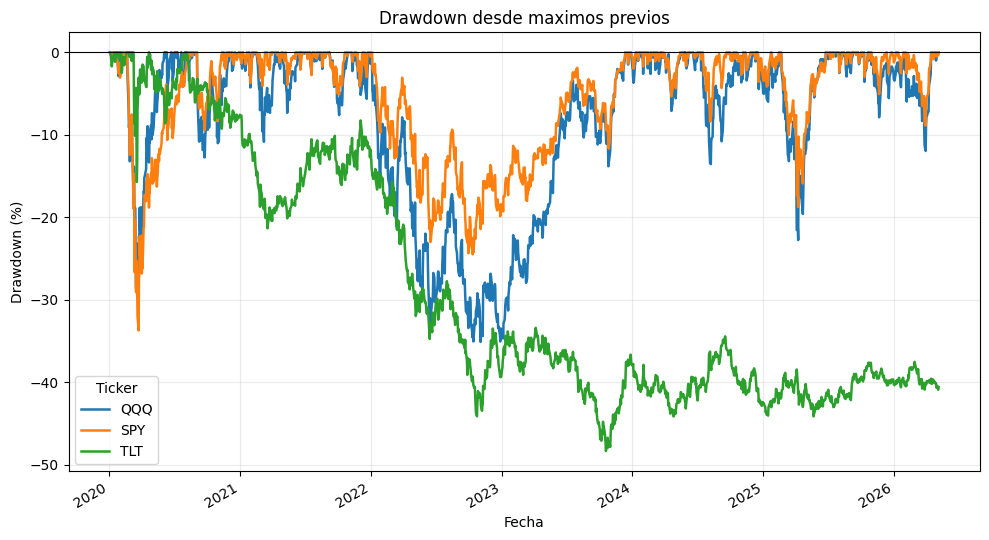

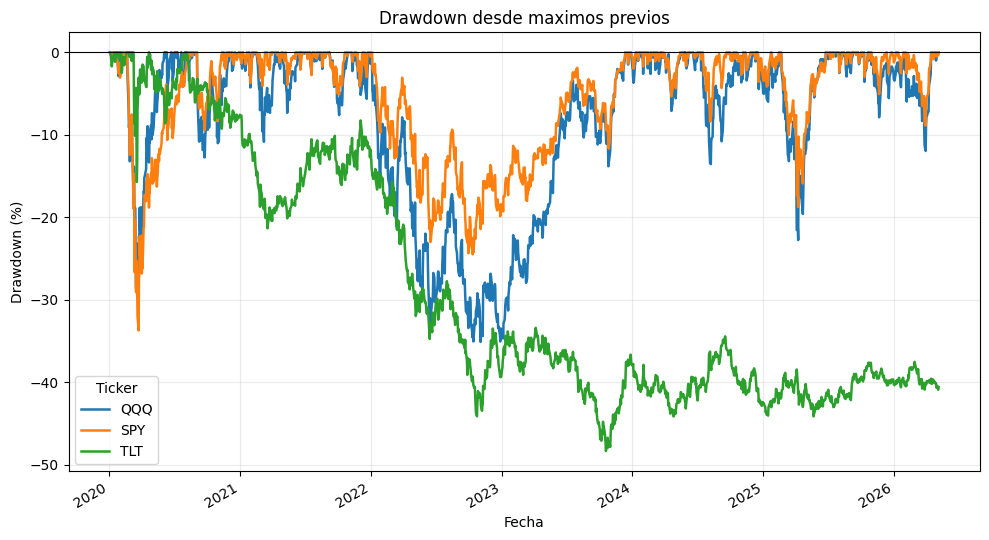

In [6]:
fig_dd, ax = plt.subplots(figsize=(10, 5.5))
(drawdown * 100).plot(ax=ax, linewidth=1.8)
ax.set_title("Drawdown desde maximos previos")
ax.set_ylabel("Drawdown (%)")
ax.set_xlabel("Fecha")
ax.axhline(0, color="black", linewidth=0.8)
ax.grid(True, alpha=0.25)
ax.legend(title="Ticker")
fig_dd.tight_layout()
fig_dd

## 6. Exportar outputs

Guardamos datos derivados, tabla, figuras y metadata de descarga.

In [7]:
combined = pd.concat(
    {
        "price": prices,
        "simple_return": returns_simple,
        "log_return": returns_log,
        "wealth_index": wealth_index,
        "drawdown": drawdown,
    },
    axis=1,
)

processed_path = DATA_PROCESSED / "chapter_02_retornos_rendimiento_drawdown.csv"
summary_path = OUTPUT_TABLES / "chapter_02_resumen_riesgo_retorno.csv"
acc_path = OUTPUT_FIGURES / "chapter_02_rendimiento_acumulado.png"
dd_path = OUTPUT_FIGURES / "chapter_02_drawdown.png"
metadata_path = OUTPUT_REPORTS / "chapter_02_metadata_descarga.md"

combined.to_csv(processed_path, encoding="utf-8")
summary.to_csv(summary_path, encoding="utf-8")
fig_acc.savefig(acc_path, dpi=170)
fig_dd.savefig(dd_path, dpi=170)

metadata = f"""# Metadata de descarga - Capitulo 2

- Fuente: Yahoo Finance via yfinance.
- Tickers: {', '.join(tickers)}.
- Fecha inicial: {start_date}.
- Fecha final: ultima disponible al momento de descarga.
- Fecha de descarga: {download_timestamp}.
- Campo de precio usado: {price_field}.
- Frecuencia: diaria.
- Uso recomendado: docencia y prototipos.
- Advertencia: rendimiento pasado no implica rendimiento futuro.
"""
metadata_path.write_text(metadata, encoding="utf-8")

for path in [processed_path, summary_path, acc_path, dd_path, metadata_path]:
    print(path.relative_to(BOOK_ROOT))

data\processed\chapter_02_retornos_rendimiento_drawdown.csv
outputs\tables\chapter_02_resumen_riesgo_retorno.csv
outputs\figures\chapter_02_rendimiento_acumulado.png
outputs\figures\chapter_02_drawdown.png
outputs\reports\chapter_02_metadata_descarga.md


## 7. Interpretacion prudente

El rendimiento acumulado muestra crecimiento relativo dentro de la muestra. El drawdown muestra perdidas desde maximos previos. Ninguna de estas medidas, por si sola, permite recomendar inversiones o predecir desempeno futuro.